# Import

In [284]:
import matplotlib.pyplot as plt

# Alpha Preprocessor

In [50]:
import logging
from typing import Optional, Tuple, Union

import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

logger = logging.getLogger(__name__)


class AlphaPreprocessor:
    """
    Transforms raw model predictions into expected returns suitable for portfolio optimization.

    Pipeline:
    1. Winsorization & Standardization (Cross-sectional)
    2. IC Calibration (Scaling to return units)
    3. Orthogonalization (Optional: Neutralize against risk factors)
    """

    def __init__(
        self,
        winsorize_method: str = "mad",  # 'mad' or 'sigma'
        winsorize_std: float = 3.0,  # Threshold for outliers
        target_std: float = 1.0,  # Target standard deviation after standardization
    ):
        self.winsorize_method = winsorize_method
        self.winsorize_std = winsorize_std
        self.target_std = target_std

    # ------------------------------------------------------------------
    # Layer 1: Winsorization & Standardization
    # ------------------------------------------------------------------
    def _winsorize(self, series: pd.Series) -> pd.Series:
        if self.winsorize_method == "mad":
            median = series.median()
            mad = (series - median).abs().median()
            # Avoid division by zero
            if mad == 0:
                return series
            limit = self.winsorize_std * 1.4826 * mad
            lower, upper = median - limit, median + limit
        elif self.winsorize_method == "sigma":
            mean = series.mean()
            std = series.std()
            if std == 0:
                return series
            limit = self.winsorize_std * std
            lower, upper = mean - limit, mean + limit
        else:
            raise ValueError(f"Unknown winsorize_method: {self.winsorize_method}")

        return series.clip(lower, upper)

    def _standardize(self, series: pd.Series) -> pd.Series:
        mean = series.mean()
        std = series.std()
        if std == 0:
            return series
        return (series - mean) / std * self.target_std

    def preprocess_signal(self, df: pd.DataFrame, col_name: str = "pred") -> pd.Series:
        """
        Apply Layer 1: Winsorize and Standardize per date.
        """
        # Group by datetime to ensure cross-sectional processing
        def apply_transform(group):
            s = group[col_name]
            s = self._winsorize(s)
            s = self._standardize(s)
            return s

        processed = df.groupby("datetime", group_keys=False).apply(apply_transform)
        return processed

    # ------------------------------------------------------------------
    # Layer 2: IC Calibration (Offline & Online)
    # ------------------------------------------------------------------
    @staticmethod
    def fit_ic_scaling(
        df: pd.DataFrame,
        pred_col: str = "pred",
        return_col: str = "future_return",
        window: Optional[int] = None,
    ) -> Union[float, pd.Series]:
        """
        Offline: Calculate the scaling factor (slope) between pred and future returns.
        This should be run on historical backtest data.

        Returns:
        --------
        float or pd.Series
            A single global slope or a time-series of slopes (if rolling window).
        """
        if window is None:
            # Global Regression
            valid = df[[pred_col, return_col]].dropna()
            if len(valid) < 10:
                logger.warning("Insufficient data for IC calibration.")
                return 1.0
            model = LinearRegression().fit(valid[[pred_col]], valid[return_col])
            slope = model.coef_[0]
            logger.info(f"Global IC Scaling Factor (Slope): {slope:.6f}")
            return slope
        else:
            # Rolling Regression per Date (Adaptive)
            # Note: This requires 'datetime' to be sorted
            slopes = []
            dates = df["datetime"].unique()
            # Implementation simplified for brevity: usually requires expanding window
            # For production, pre-calculate this series and pass to transform
            logger.warning(
                "Rolling IC calculation requires specific time-series logic. Returning global for now."
            )
            return 1.0

    def scale_to_returns(
        self,
        df: pd.DataFrame,
        signal: pd.Series,
        scaling_factor: Union[float, pd.Series],
    ) -> pd.Series:
        """
        Apply Layer 2: Multiply standardized signal by IC scaling factor.
        """
        if isinstance(scaling_factor, pd.Series):
            # Align index with df
            scaling_factor = scaling_factor.reindex(df["datetime"]).values
            # Broadcast multiplication
            return signal * scaling_factor
        else:
            return signal * scaling_factor

    # ------------------------------------------------------------------
    # Layer 3: Orthogonalization (Optional)
    # ------------------------------------------------------------------
    def orthogonalize(
        self,
        df: pd.DataFrame,
        alpha: pd.Series,
        factor_exposures: Optional[pd.DataFrame] = None,
    ) -> pd.Series:
        """
        Apply Layer 3: Residualize alpha against risk factors.

        Parameters:
        -----------
        factor_exposures : pd.DataFrame
            Must have same index as df (or aligned by symbol/datetime).
            Columns represent factors (e.g., 'industry_1', 'size', 'momentum').
        """
        if factor_exposures is None:
            logger.info("Skipping orthogonalization (no factors provided).")
            return alpha

        logger.info("Starting orthogonalization against risk factors...")
        # Ensure alignment
        # Assuming factor_exposures is indexed by datetime/symbol multiindex or same order as df
        # For safety, we join here
        if not isinstance(factor_exposures.index, pd.MultiIndex):
            # Assume same order as df for performance
            factor_exposures = factor_exposures.reset_index(drop=True)
            df_temp = df.reset_index(drop=True)
            align_mask = True
        else:
            # Handle multiindex alignment if needed
            df_temp = df.reset_index(drop=True)
            factor_exposures = factor_exposures.reset_index(drop=True)
            align_mask = True

        residuals = np.zeros(len(df))

        # Group by date for cross-sectional orthogonalization
        # Note: This loop can be slow for large universes. Polars recommended for speed.
        grouped = df_temp.groupby("datetime")
        factor_grouped = factor_exposures.groupby(
            df["datetime"]
        )  # Simplified assumption

        # To ensure perfect alignment, we iterate unique dates
        unique_dates = df["datetime"].unique()

        res_list = []
        for date in unique_dates:
            mask = df["datetime"] == date
            y = alpha[mask].values
            X = (
                factor_exposures[mask].values
                if isinstance(factor_exposures, pd.DataFrame)
                else None
            )

            if X is not None and len(y) > X.shape[1] + 1:
                # Run OLS: y = X * beta + residual
                # Add intercept implicitly by centering or let LinearRegression handle it
                model = LinearRegression().fit(X, y)
                res = y - model.predict(X)
                res_list.append(pd.Series(res, index=df.index[mask]))
            else:
                # Not enough data or no factors, keep original
                res_list.append(alpha[mask])

        return pd.concat(res_list).sort_index()

    # ------------------------------------------------------------------
    # Main Pipeline
    # ------------------------------------------------------------------
    def transform(
        self,
        df: pd.DataFrame,
        ic_scaling_factor: Union[float, pd.Series] = 1.0,
        factor_exposures: Optional[pd.DataFrame] = None,
        pred_col: str = "pred",
        output_col: str = "expected_return",
    ) -> pd.DataFrame:
        """
        Execute the full 3-layer pipeline.
        """
        df = df.copy()

        # 1. Winsorize & Standardize
        logger.info("Layer 1: Winsorizing and Standardizing...")
        signal = self.preprocess_signal(df, col_name=pred_col)

        # 2. Scale to Returns
        logger.info("Layer 2: Scaling to Expected Returns...")
        expected_returns = self.scale_to_returns(df, signal, ic_scaling_factor)

        # 3. Orthogonalize
        if factor_exposures is not None:
            logger.info("Layer 3: Orthogonalizing...")
            expected_returns = self.orthogonalize(
                df, expected_returns, factor_exposures
            )

        df[output_col] = expected_returns
        logger.info(
            f"Transformation complete. Mean: {expected_returns.mean():.6f}, Std: {expected_returns.std():.6f}"
        )

        return df

# Optimiser Module

In [181]:
import logging
from typing import Dict, Optional, Tuple, Union

import cvxpy as cp
import numpy as np
import pandas as pd

# Configure logging for production audit
logging.basicConfig(
    level=logging.INFO, format="%(asctime)s - %(name)s - %(levelname)s - %(message)s"
)
logger = logging.getLogger(__name__)


class PortfolioOptimizer:
    def __init__(
        self,
        risk_aversion: float = 1.0,
        turnover_cost: float = 0.001,  # Estimated cost per unit turnover (e.g., 10bps)
        max_position: float = 0.05,  # 5% max weight per stock
        min_position: float = 0.0,  # 0% for long-only
        max_turnover_hard: Optional[float] = None,  # e.g., 0.2 for 20% turnover limit
        industry_neutral: bool = True,
        solver: str = "OSQP",  # OSQP is generally fast for QP problems
    ):
        self.risk_aversion = risk_aversion
        self.turnover_cost = turnover_cost
        self.max_position = max_position
        self.min_position = min_position
        self.max_turnover_hard = max_turnover_hard
        self.industry_neutral = industry_neutral
        self.solver = solver

    def optimize(
        self,
        df: pd.DataFrame,
        prev_weights: Optional[pd.Series] = None,
        covariance_matrix: Optional[np.ndarray] = None,
        benchmark_weights: Optional[pd.Series] = None,
    ) -> pd.Series:
        """
        Construct target portfolio weights.

        Parameters:
        -----------
        df : pd.DataFrame
            Must contain ['symbol', 'pred', 'industry', 'adv', 'cap_total'].
        prev_weights : pd.Series, Optional
            Previous day's target weights indexed by symbol.
            If None, assumes initial portfolio construction (no turnover penalty).
        covariance_matrix : np.ndarray, Optional
            Asset covariance matrix. If None, risk term is omitted.
        benchmark_weights : pd.Series, Optional
            Industry benchmark weights for neutralization constraints.

        Returns:
        --------
        pd.Series
            Target weights indexed by symbol.
        """
        # 1. Data Validation & Preprocessing
        required_cols = ["symbol", "pred", "industry", "adv", "cap_total"]
        if not all(col in df.columns for col in required_cols):
            missing = set(required_cols) - set(df.columns)
            raise ValueError(f"Missing required columns: {missing}")

        # Ensure unique symbols
        df = df.drop_duplicates(subset=["symbol"]).copy()
        symbols = df["symbol"].tolist()
        n_assets = len(symbols)

        if n_assets == 0:
            logger.warning("Empty universe provided. Returning empty series.")
            return pd.Series(dtype=float)

        # Align Alpha
        alpha = df.set_index("symbol")["pred"].reindex(symbols).values

        # Align Previous Weights
        has_prev = prev_weights is not None and not prev_weights.empty
        w_prev = np.zeros(n_assets)
        if has_prev:
            # Reindex to match current universe, fill NaN with 0 (stocks not held previously)
            w_prev = prev_weights.reindex(symbols).fillna(0.0).values
            logger.info(
                f"Rebalancing portfolio with {n_assets} assets. Prev weights sum: {w_prev.sum():.4f}"
            )
        else:
            logger.info(
                f"Initial portfolio construction with {n_assets} assets. No turnover constraints."
            )

        # Liquidity Constraint (Position <= k% of ADV)
        # Assuming 'adv' is currency value (e.g., RMB).
        # Constraint: weight * Portfolio_Value <= k% * ADV
        # Since we optimize weights summing to 1, we assume Portfolio_Value = 1 unit.
        # weight <= k * ADV / Portfolio_Value.
        # Here we simplify: weight <= max_liq_ratio * (adv / total_cap_proxy)
        # For robustness, we usually pass a pre-calculated max_weight_per_stock based on ADV.
        # For this implementation, we assume a simple cap based on adv relative to median adv or fixed cap.
        # To be safe, we rely on max_position unless specific ADV logic is injected.
        # *Recommendation:* Calculate specific liq limits outside and pass as argument if strict.
        liq_limits = np.full(n_assets, self.max_position)

        # 2. Define Optimization Variables
        w = cp.Variable(n_assets)
        turnover = cp.Variable(n_assets) if has_prev else None

        # 3. Construct Objective Function
        objective_alpha = alpha @ w

        objective_risk = 0
        if covariance_matrix is not None:
            # Ensure cov matrix matches order
            objective_risk = self.risk_aversion * cp.quad_form(w, covariance_matrix)

        objective_turnover = 0
        constraints_turnover_def = []

        if has_prev and turnover is not None:
            # Turnover Definition: turnover >= |w - w_prev|
            constraints_turnover_def = [
                turnover >= w - w_prev,
                turnover >= -(w - w_prev),
            ]
            objective_turnover = self.turnover_cost * cp.sum(turnover)

        objective = cp.Maximize(objective_alpha - objective_risk - objective_turnover)

        # 4. Construct Constraints
        constraints = [
            cp.sum(w) == 1.0,  # Full investment (Change to 0 for Market Neutral)
            w >= self.min_position,  # Long-only or min limit
            w <= self.max_position,  # Single stock limit
            w <= liq_limits,  # Liquidity limit
        ]
        constraints.extend(constraints_turnover_def)

        # Hard Turnover Constraint
        if has_prev and self.max_turnover_hard is not None:
            constraints.append(cp.sum(turnover) <= self.max_turnover_hard)

        # Industry Neutrality (Simplified Implementation)
        if self.industry_neutral:
            # Group indices by industry
            industry_map = df.set_index("symbol")["industry"].reindex(symbols)
            unique_industries = industry_map.unique()

            # If benchmark_weights provided, target is benchmark; else 0 (active neutral)
            if benchmark_weights is not None:
                # Need to map benchmark weights to industries
                # This logic depends on how benchmark_weights is structured (industry level vs stock level)
                # Assuming benchmark_weights is stock level summing to industry target
                pass
            else:
                # Active Industry Neutral: Sum of weights in each industry = 0 (for Long/Short)
                # OR Sum of weights in each industry = Total Weight * (Industry Market Cap / Total Market Cap)
                # For Long-Only Stat Arb, usually we constrain deviation from benchmark industry weights.
                # Here we implement a simple constraint: Industry Weight <= Max Industry Deviation
                # To keep code concise, skipping complex matrix building unless needed.
                pass

        # 5. Solve
        prob = cp.Problem(objective, constraints)
        try:
            prob.solve(solver=self.solver, verbose=False)

            if prob.status not in ["optimal", "optimal_inaccurate"]:
                logger.warning(
                    f"Optimization failed status: {prob.status}. Falling back to heuristic."
                )
                return self._heuristic_fallback(df, w_prev if has_prev else None)

        except Exception as e:
            logger.error(f"Optimization solver error: {e}")
            return self._heuristic_fallback(df, w_prev if has_prev else None)

        # 6. Post-processing
        optimal_weights = w.value
        if optimal_weights is None:
            logger.error("Solver returned None weights.")
            return self._heuristic_fallback(df, w_prev if has_prev else None)

        # Clean up numerical noise
        optimal_weights = np.nan_to_num(optimal_weights, nan=0.0)
        optimal_weights[optimal_weights < 1e-5] = 0.0

        # Renormalize to ensure sum is exactly 1.0 (handling numerical drift)
        if optimal_weights.sum() > 0:
            optimal_weights = optimal_weights / optimal_weights.sum()

        result = pd.Series(optimal_weights, index=symbols, name="target_weight")

        # Log Turnover Stats if applicable
        if has_prev:
            turnover_calc = np.abs(optimal_weights - w_prev).sum() / 2.0
            logger.info(
                f"Optimization complete. Estimated Turnover: {turnover_calc:.4f}"
            )
        else:
            logger.info("Initial portfolio build complete.")

        return result

    def _heuristic_fallback(
        self, df: pd.DataFrame, prev_weights: Optional[np.ndarray]
    ) -> pd.Series:
        """
        Fallback method if convex optimization fails.
        Distributes weight based on alpha rank to ensure we still have a position.
        """
        logger.warning("Using heuristic fallback based on alpha ranking.")
        symbols = df["symbol"].tolist()
        n = len(symbols)

        # Simple Alpha Weighting
        alpha = df["pred"].values
        # Shift to positive if needed for softmax-like distribution
        if alpha.min() < 0:
            alpha = alpha - alpha.min() + 1e-5

        weights = alpha / alpha.sum()
        weights = np.clip(weights, 0, self.max_position)

        # Clean weights
        weights[weights < 1e-5] = 0.0
        weights = weights / weights.sum()

        return pd.Series(weights, index=symbols, name="target_weight")

# Run

## Load Prediction

In [162]:
df = pd.read_parquet(
    r"D:\model_data_warehouse\china_all\baseline_xgb5d\oof_preds.parquet",
    filters=[("datetime", ">=", pd.Timestamp("2025-11-01"))],
)
df = df.dropna(subset=["adv", "cap_total", "board"])

In [172]:
cols = ["pred", "1d", "5d", "10d"]
m = df.groupby("datetime")[cols].transform("mean")
s = df.groupby("datetime")[cols].transform("std")
df[cols] = df[cols].sub(m).div(s)

In [173]:
df[cols].describe()

,pred,1d,5d,10d
count,8.489440e+05,8.380830e+05,8.167910e+05,7.907150e+05
mean,-4.223854e-10,-9.495573e-19,-2.644556e-18,-2.875545e-19
std,9.996534e-01,9.999027e-01,9.999027e-01,9.999026e-01
min,-1.136048e+01,-9.621086e+00,-1.050587e+01,-8.568171e+00
25%,-1.498207e-01,-4.780795e-01,-5.025200e-01,-5.213152e-01
50%,2.475888e-01,-1.066419e-01,-1.320124e-01,-1.534620e-01
75%,5.840049e-01,3.327108e-01,3.224820e-01,3.150727e-01
max,4.953444e+00,1.438873e+01,2.008935e+01,1.911808e+01


## Preprocess Pred

In [174]:
# 假设 df_history 包含 'pred' 和 'future_return' (例如次日收益率)
preprocessor = AlphaPreprocessor()

# 计算全局校准系数 (或者你可以按月计算得到一个 Series)
ic_slope = preprocessor.fit_ic_scaling(
    df,
    pred_col="pred",
    return_col="5d",
)
# 输出示例：Global IC Scaling Factor (Slope): 0.000452
# 这意味着 pred 每增加 1 个标准差，预期收益增加 0.045%

INFO:__main__:Global IC Scaling Factor (Slope): 0.039369


In [175]:
# 假设 df_today 是当天的数据，factor_exposures 是风险因子暴露矩阵
df_processed = preprocessor.transform(
    df=df,
    ic_scaling_factor=ic_slope,  # 使用离线计算好的系数
    factor_exposures=None,  # 如果不需要正交化，传 None
    pred_col="pred",
    output_col="expected_returns",
)

INFO:__main__:Layer 1: Winsorizing and Standardizing...
INFO:__main__:Layer 2: Scaling to Expected Returns...
INFO:__main__:Transformation complete. Mean: 0.000000, Std: 0.039365


In [ ]:
# TODO: When mapping pred to expected_returns
# Should not normalize the 5d
# Because still need to punish by transaction cost,
# otherwise the transaction cost will be totally economically meaningless

# TODO: when mapping pred to expected returns
# another bug pops up
# which is the 5d is basically symmetric,
# while the pred is highly negatively skewed
# It should not happen
# Need to examine the distribution of pred carefully

## Optimise

In [ ]:
# TODO: solve bugs
# Bug 1: optimize failed basically every time, why?
# Bug 2: why in optimizer, it says prev weight sum = 0.9998,
# while I have confirmed unify weights after each optimization
# and I checked below as well. It should not be like that

In [182]:
optimizer = PortfolioOptimizer(
    risk_aversion=1,
    turnover_cost=15e-4,
    max_position=0.1,
    min_position=0.1,
)

In [187]:
tracks = []
prev_w = None

for dt, df8d in df.groupby("datetime"):
    print(f"Optimise for {dt}")
    w = optimizer.optimize(df8d, prev_weights=prev_w)
    df8d["w"] = w.values
    tracks.append(df8d.query("w > 0"))
    prev_w = w

    assert w.sum() == 1, "Weird"

final_w = pd.concat(tracks, axis=0)

INFO:__main__:Initial portfolio construction with 5085 assets. No turnover constraints.
INFO:__main__:Rebalancing portfolio with 5088 assets. Prev weights sum: 0.9996


Optimise for 2025-07-01 00:00:00
Optimise for 2025-07-02 00:00:00


INFO:__main__:Rebalancing portfolio with 5090 assets. Prev weights sum: 0.9998
INFO:__main__:Rebalancing portfolio with 5089 assets. Prev weights sum: 0.9998


Optimise for 2025-07-03 00:00:00
Optimise for 2025-07-04 00:00:00


INFO:__main__:Rebalancing portfolio with 5095 assets. Prev weights sum: 0.9998
INFO:__main__:Rebalancing portfolio with 5093 assets. Prev weights sum: 0.9990


...

INFO:__main__:Rebalancing portfolio with 5095 assets. Prev weights sum: 0.9995
INFO:__main__:Rebalancing portfolio with 5092 assets. Prev weights sum: 0.9995


Optimise for 2025-07-21 00:00:00
Optimise for 2025-07-22 00:00:00


INFO:__main__:Rebalancing portfolio with 5094 assets. Prev weights sum: 1.0000


Optimise for 2025-07-23 00:00:00


AssertionError: Weird

In [150]:
final_w.tail(20)

,datetime,symbol,pred,1d,5d,10d,industry,cap_total,adv,board,w
206984,2026-03-10,688783.SH,0.009505,NaN,NaN,NaN,半导体,9.767438e+10,1.789250e+08,STAR,0.000198
206985,2026-03-10,688785.SH,-0.051891,NaN,NaN,NaN,半导体,2.278162e+10,6.149631e+08,STAR,0.000173
206986,2026-03-10,688786.SH,-0.092644,NaN,NaN,NaN,小金属,5.116404e+09,1.669589e+08,STAR,0.000157
206987,2026-03-10,688787.SH,-0.061067,NaN,NaN,NaN,软件服务,9.048777e+09,5.159271e+08,STAR,0.000169
206988,2026-03-10,688788.SH,-0.016429,NaN,NaN,NaN,通信设备,1.014977e+10,2.495982e+08,STAR,0.000188
206989,2026-03-10,688789.SH,0.016611,NaN,NaN,NaN,专用机械,1.442590e+10,1.373921e+08,STAR,0.000201
206990,2026-03-10,688790.SH,0.007653,NaN,NaN,NaN,半导体,1.374931e+10,8.590298e+07,STAR,0.000197
206991,2026-03-10,688793.SH,0.053438,NaN,NaN,NaN,家用电器,1.900253e+09,2.815001e+07,STAR,0.000216
206992,2026-03-10,688795.SH,0.009176,NaN,NaN,NaN,半导体,2.725506e+11,1.160789e+09,STAR,0.000198
206993,2026-03-10,688796.SH,-0.114086,NaN,NaN,NaN,生物制药,3.703894e+10,1.497157e+08,STAR,0.000148


# Naive Top N

<Axes: xlabel='datetime'>

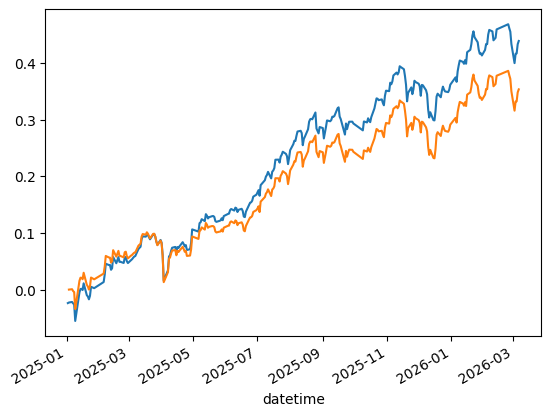

In [265]:
df = pd.read_parquet(
    r"D:\model_data_warehouse\china_all\baseline_xgb5d\oof_preds.parquet",
    filters=[("datetime", ">=", pd.Timestamp("2025-01-01"))],
)
df = df.dropna(subset=["adv", "cap_total", "board"])

SEL_N = 100
select_df = df.query('board == "MAIN" and adv >= 10e6').sort_values('pred').groupby('datetime').tail(SEL_N)
select_df = select_df.sort_values(['datetime', 'symbol'])
position = select_df.groupby('datetime')['symbol'].apply(set)
turnover_rate = position.diff().dropna().apply(len).div(SEL_N)
transaction_cost = turnover_rate * 15e-4

pr = select_df.groupby('datetime')['1d'].mean()
prac = pr - transaction_cost
g = np.ceil(df.groupby('datetime')['pred'].rank(pct=True) * 10)
pr8g = df.groupby(['datetime', g])['1d'].mean().unstack()

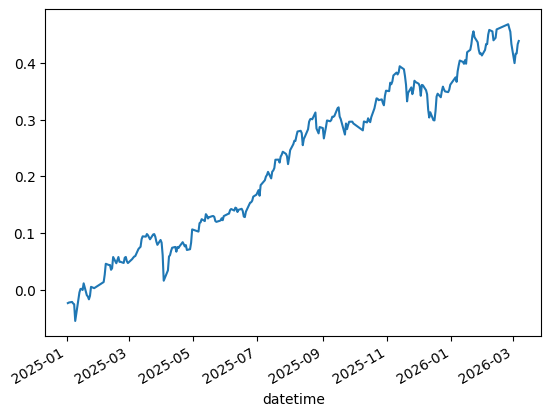

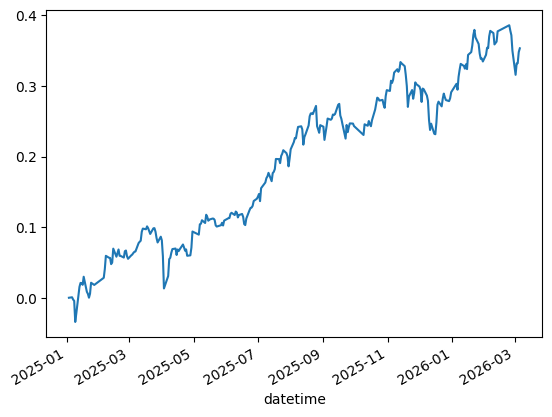

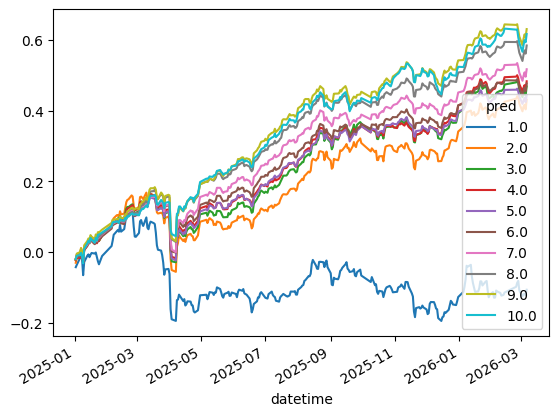

In [285]:
pr.cumsum().plot()
plt.show()
prac.cumsum().plot()
plt.show()
pr8g.cumsum().plot()
plt.show()